In [8]:
# Общие настройки
import os, math, random, re, json, time
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5,3)

import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer as SkTFIDF


RNG_SEED = 42
def set_seed(seed=RNG_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()

# viz helpers
def plot_curve(values, title, ylabel="score", xlabel="step"):
    xs = np.arange(1, len(values)+1)
    plt.plot(xs, values, marker="o")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(True)
    plt.show()

def plot_confusion(cm, labels):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels, ylabel='True', xlabel='Pred')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout(); plt.show()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## Собственный TF-IDF + baseline-классификатор

**Задача:** классификация новостей

**Данные:** ag_news (HuggingFace)

**Результаты:** accuracy/macro F1 + сравнение с sklearn tfidf

In [9]:
# --- data loader ---
def load_ag_news_or_stub(n_train=8000, n_test=2000):
        from datasets import load_dataset
        ds = load_dataset("ag_news")
        train = ds["train"].select(range(min(n_train, len(ds["train"]))))
        test  = ds["test"].select(range(min(n_test , len(ds["test"]))))
        return (list(train["text"]), list(train["label"])), (list(test["text"]), list(test["label"]))

(train_x, train_y), (test_x, test_y) = load_ag_news_or_stub()
len(train_x), len(test_x)

(8000, 2000)

In [10]:
class MyTfidfVectorizer:
    def __init__(self, min_df=1, max_df=1.0, max_features=None,
                 ngram_range=(1,1), use_idf=True, smooth_idf=True,
                 sublinear_tf=False, norm='l2', lowercase=True):
        self.min_df=min_df; self.max_df=max_df; self.max_features=max_features
        self.ngram_range=ngram_range; self.use_idf=use_idf; self.smooth_idf=smooth_idf
        self.sublinear_tf=sublinear_tf; self.norm=norm; self.lowercase=lowercase
        self.vocab_ = {}
        self.idf_ = None
        self._fitted = False

    def _tokenize(self, text):
        import re
        res = []
        if self.lowercase:
            text = text.lower()
        return re.findall(r"[a-z0-9]+", text)

    def _generate_ngrams(self, tokens):
        res = []
        for i in range(self.ngram_range[0], self.ngram_range[1] + 1):
            for j in range(len(tokens) - i + 1):
                res.append(" ".join(tokens[j:j+i]))

        return res

    def fit(self, corpus):
        from collections import defaultdict
        from math import log

        N = len(corpus)

        df = defaultdict(int)
        for doc in corpus:
            tokens = self._tokenize(doc)
            ngrams = self._generate_ngrams(tokens)
            unique_ngrams = set(ngrams)
            for ngr in unique_ngrams:
              df[ngr] += 1

        sorted_df = sorted(df.items(), key=lambda x: x[1], reverse=True)
        sorted_df = sorted_df[:self.max_features]

        if isinstance(self.min_df, float):
            min_df = self.min_df * N
        else:
            min_df = self.min_df

        if isinstance(self.max_df, float):
            max_df = int(self.max_df * N)
            if max_df < 1:
                max_df = 1
        else:
            max_df = self.max_df

        filtered = [(t, v) for t, v in df.items() if min_df <= v <= max_df]
        filtered.sort(key=lambda x: (-x[1], x[0]))

        if self.max_features:
          filtered = filtered[:self.max_features]

        self.vocab_ = {}
        for idx, (t, df_val) in enumerate(filtered):
            self.vocab_[t] = idx

        if self.use_idf:
            self.idf_ = [0.0] * len(self.vocab_)
            for t, idx in self.vocab_.items():
                df_t = df[t]
                if self.smooth_idf:
                    idf_val = 1.0 + log((1.0 + N) / (1.0 + df_t))
                else:
                    idf_val = 1.0 + log(N / df_t)
                self.idf_[idx] = idf_val
        else:
            self.idf_ = [1.0] * len(self.vocab_)

        self._fitted = True
        return self


    def transform(self, corpus):
        from math import sqrt, log
        from scipy.sparse import csr_matrix

        if not self._fitted:
            raise ValueError()

        n_features = len(self.vocab_)

        data = []
        indices = []
        indptr = [0]

        for doc in corpus:
            tokens = self._tokenize(doc)
            ngrams = self._generate_ngrams(tokens)

            tf = {}
            for ngr in ngrams:
                idx = self.vocab_.get(ngr)
                if idx is not None:
                    tf[idx] = tf.get(idx, 0.0) + 1.0

            if self.sublinear_tf:
                for idx in tf:
                    tf[idx] = 1.0 + log(tf[idx])

            row_vals = {}
            for idx, tf_val in tf.items():
                row_vals[idx] = tf_val * self.idf_[idx]

            if self.norm in ('l1', 'l2') and row_vals:
                if self.norm == 'l1':
                    normas = sum(abs(v) for v in row_vals.values())
                else:
                    normas = sqrt(sum(v * v for v in row_vals.values()))
                if normas > 0.0:
                    for idx in row_vals:
                        row_vals[idx] /= normas

            for idx, val in row_vals.items():
                indices.append(idx)
                data.append(val)

            indptr.append(len(data))

        X = csr_matrix((data, indices, indptr), shape=(len(corpus), n_features))
        return X



    def fit_transform(self, corpus):
      self.fit(corpus)
      X = self.transform(corpus)
      return X.toarray()

    def get_feature_names_out(self):
        return list(self.vocab_.keys())


[TF-IDF + LR] accuracy = 0.8755


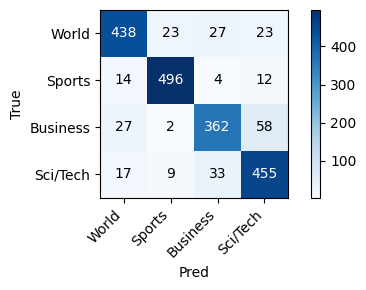

In [11]:
# --- Обучение + метрика ---
vec = MyTfidfVectorizer(min_df=3, max_df=0.9, max_features=100000,
                        ngram_range=(1,2), use_idf=True, smooth_idf=True,
                        sublinear_tf=True, norm='l2')

Xtr = vec.fit_transform(train_x)
Xte = vec.transform(test_x)

clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, train_y)
pred = clf.predict(Xte)
acc = accuracy_score(test_y, pred)
print(f"[TF-IDF + LR] accuracy = {acc:.4f}")

# Confusion matrix
label_names = ["World","Sports","Business","Sci/Tech"]
cm = confusion_matrix(test_y, pred, labels=[0,1,2,3])
plot_confusion(cm, labels=label_names)

In [12]:
subset = train_x[:100]
vec_small = MyTfidfVectorizer(min_df=3, max_df=0.9, max_features=50000,
                              ngram_range=(1,2), use_idf=True, smooth_idf=True,
                              sublinear_tf=True, norm='l2')

sk = SkTFIDF(min_df=3, max_df=0.9, max_features=50000,
             ngram_range=(1,2), use_idf=True, smooth_idf=True,
             sublinear_tf=True, norm='l2')

skX = sk.fit_transform(subset).toarray()
myX = vec_small.fit_transform(subset)

i = 0
cos_my = (myX[i] @ myX[i]) / (norm(myX[i]) * norm(myX[i]) + 1e-12)
cos_sk = (skX[i] @ skX[i]) / (norm(skX[i]) * norm(skX[i]) + 1e-12)
assert abs(cos_my - cos_sk) < 1e-6, "TF-IDF не совпал со sklearn по косинусу"

min_df=1: acc=0.8770
min_df=2: acc=0.8770
min_df=4: acc=0.8760
min_df=8: acc=0.8750
min_df=16: acc=0.8560


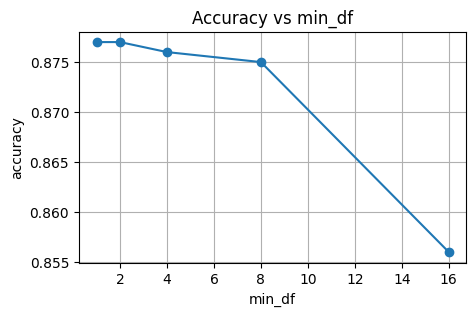

In [13]:
dfs = [1, 2, 4, 8, 16]
scores = []

for df in dfs:
  vec = MyTfidfVectorizer(
      min_df=df,
      max_df=0.9,
      max_features=50000,
      ngram_range=(1,2),
      use_idf=True,
      smooth_idf=True,
      sublinear_tf=True,
      norm='l2'
  )
  Xtr = vec.fit_transform(train_x)
  Xte = vec.transform(test_x)

  clf = LogisticRegression(max_iter=1000, random_state=42)
  clf.fit(Xtr, train_y)
  pred = clf.predict(Xte)
  acc = accuracy_score(test_y, pred)
  scores.append(acc)
  print(f"min_df={df}: acc={acc:.4f}")

plt.plot(dfs, scores, marker='o')
plt.xlabel("min_df")
plt.ylabel("accuracy")
plt.title("Accuracy vs min_df")
plt.grid(True)
plt.show()

In [14]:
features = np.array(vec.get_feature_names_out())
coefs = clf.coef_

labels = ["World","Sports","Business","Sci/Tech"]

for class_idx, label in enumerate(labels):
    coef = coefs[class_idx]
    topn = np.argsort(coef)[-10:]
    print(f"\nТоп-10 фичей для класса {label}:")
    for idx in topn[::-1]:
        print(f"{features[idx]:20s}  {coef[idx]:.4f}")



Топ-10 фичей для класса World:
afp                   3.5670
minister              2.6907
athens greece         2.5152
leader                2.1647
military              2.1459
war                   2.1038
president             2.0794
najaf                 2.0502
afp afp               2.0447
government            2.0114

Топ-10 фичей для класса Sports:
athens                3.9647
olympic               3.2112
his                   3.0312
coach                 2.5468
season                2.5052
league                2.4232
athens reuters        2.3966
team                  2.2380
the                   2.2261
ap                    2.2119

Топ-10 фичей для класса Business:
oil                   3.4520
company               2.6470
billion               2.3692
business              2.3383
profit                2.2138
tax                   2.0271
airlines              2.0200
financial             1.7916
its                   1.7865
strike                1.7462

Топ-10 фичей для класса Sci/T